# 05 三模型线推理验证（CSEE）

本 Notebook 用于在 `CSEE_human_llm_balanced.csv` 上完成三条模型线预测与融合：
- Linear：TF-IDF + MNB + SGD soft voting
- DistilRoBERTa：加载本地已微调 checkpoint 直接推理
- DeBERTa：从 HuggingFace 下载的 `deberta-v3-small` 权重（若无已微调权重则先微调再推理）

输出：
- `outputs/csee_three_line_predictions.csv`
- `outputs/csee_three_line_metrics.csv`


In [1]:
# 如需安装依赖，取消注释
# !pip install -q pandas numpy scikit-learn datasets transformers accelerate

In [4]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import Dataset
from sklearn.ensemble import VotingClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import roc_auc_score, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
import torch
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
)



In [5]:
ROOT = Path.cwd()
if not (ROOT / 'CESS').exists() and (ROOT.parent / 'CESS').exists():
    ROOT = ROOT.parent

DATA_CSV = ROOT / 'CESS' / 'CSEE_human_llm_balanced.csv'
OUT_DIR = ROOT / 'outputs'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Distil checkpoint 自动探测
DISTIL_CANDIDATES = [
    ROOT / 'output' / 'oralia_distil' / 'distilroberta_experiments' / 'distilroberta_hparam_E2' / 'model' / 'checkpoint-17765',
    ROOT / 'output' / 'oralia_distil' / 'distilroberta_experiments' / 'distilroberta_hparam_E2' / 'model' / 'checkpoint-14214',
    ROOT / 'output' / 'oralia_distil' / 'distilroberta_experiments' / 'distilroberta_hparam_E1' / 'model' / 'checkpoint-10659',
]
DISTIL_CKPT = next((p for p in DISTIL_CANDIDATES if (p / 'pytorch_model.bin').exists()), None)

# DeBERTa: 已下载HF base权重
DEBERTA_BASE = ROOT / 'models' / 'deberta' / 'deberta-v3-small-hf'
DEBERTA_FINETUNED = ROOT / 'models' / 'deberta' / 'deberta-v3-small-csee-ft'

assert DATA_CSV.exists(), f'missing {DATA_CSV}'
assert DISTIL_CKPT is not None, 'Distil checkpoint not found'
assert DEBERTA_BASE.exists(), f'missing {DEBERTA_BASE}'

print('ROOT:', ROOT)
print('DATA:', DATA_CSV)
print('DISTIL_CKPT:', DISTIL_CKPT)
print('DEBERTA_BASE:', DEBERTA_BASE)
print('DEBERTA_FINETUNED:', DEBERTA_FINETUNED)


ROOT: /Users/songling/Desktop/Artificial-Intelligence-Competition---Large-Language-Model-LLM--main/LLM-Detect AI Generated Text
DATA: /Users/songling/Desktop/Artificial-Intelligence-Competition---Large-Language-Model-LLM--main/LLM-Detect AI Generated Text/CESS/CSEE_human_llm_balanced.csv
DISTIL_CKPT: /Users/songling/Desktop/Artificial-Intelligence-Competition---Large-Language-Model-LLM--main/LLM-Detect AI Generated Text/output/oralia_distil/distilroberta_experiments/distilroberta_hparam_E2/model/checkpoint-17765
DEBERTA_BASE: /Users/songling/Desktop/Artificial-Intelligence-Competition---Large-Language-Model-LLM--main/LLM-Detect AI Generated Text/models/deberta/deberta-v3-small-hf
DEBERTA_FINETUNED: /Users/songling/Desktop/Artificial-Intelligence-Competition---Large-Language-Model-LLM--main/LLM-Detect AI Generated Text/models/deberta/deberta-v3-small-csee-ft


In [6]:
df = pd.read_csv(DATA_CSV)
text_col = 'essay' if 'essay' in df.columns else 'text'
assert 'label' in df.columns, 'label column missing'

df[text_col] = df[text_col].fillna('').astype(str)
df = df[df[text_col].str.len() > 20].copy().reset_index(drop=True)
df['text_len'] = df[text_col].str.len()
full_df = df.copy()

train_df, test_df = train_test_split(
    df[[text_col, 'label']],
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

train_df = train_df.rename(columns={text_col: 'text'})
test_df = test_df.rename(columns={text_col: 'text'})

print('all:', df.shape, 'train:', train_df.shape, 'test:', test_df.shape)
print('all label:', df['label'].value_counts().to_dict())
print('train label:', train_df['label'].value_counts().to_dict())
print('test label:', test_df['label'].value_counts().to_dict())



all: (26488, 6) train: (21190, 2) test: (5298, 2)
all label: {0: 13260, 1: 13228}
train label: {0: 10608, 1: 10582}
test label: {0: 2652, 1: 2646}


## CSEE External Test Set EDA（用于答辩展示）

本节输出：
- 表5：`outputs/csee_eda/table5_csee_external_set_composition.csv`
- 图：标签分布、长度分布、prompt分布（若有prompt_id）



saved: /Users/songling/Desktop/Artificial-Intelligence-Competition---Large-Language-Model-LLM--main/LLM-Detect AI Generated Text/outputs/csee_eda/table5_csee_external_set_composition.csv
      label  count
0  Human(0)  13260
1    LLM(1)  13228


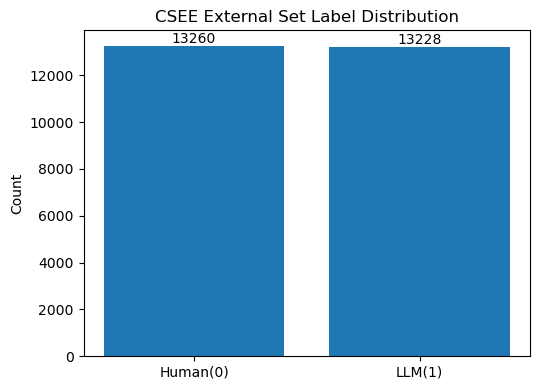

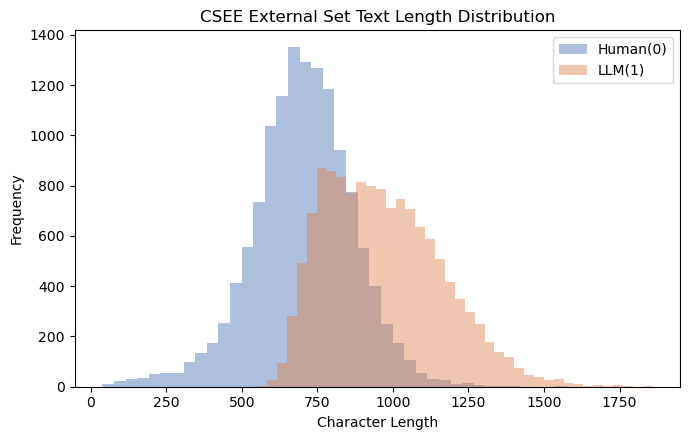

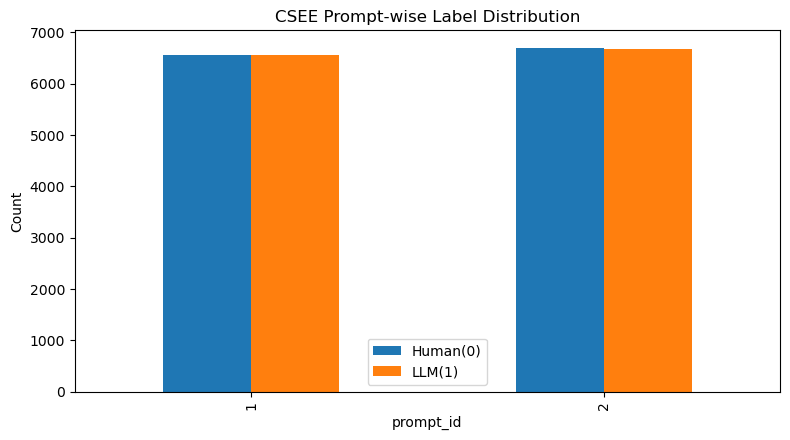

saved: /Users/songling/Desktop/Artificial-Intelligence-Competition---Large-Language-Model-LLM--main/LLM-Detect AI Generated Text/outputs/csee_eda/csee_prompt_label_distribution.csv


In [7]:
EDA_DIR = OUT_DIR / 'csee_eda'
EDA_DIR.mkdir(parents=True, exist_ok=True)

# 表5：外部验证集构成
comp = (
    full_df['label']
    .value_counts()
    .rename(index={0: 'Human(0)', 1: 'LLM(1)'})
    .rename('count')
    .reset_index()
    .rename(columns={'index': 'class'})
)
comp.to_csv(EDA_DIR / 'table5_csee_external_set_composition.csv', index=False)
print('saved:', EDA_DIR / 'table5_csee_external_set_composition.csv')
print(comp)

# 图1：标签分布
fig, ax = plt.subplots(figsize=(5.5, 4))
plot_comp = full_df['label'].value_counts().sort_index()
ax.bar(['Human(0)', 'LLM(1)'], [plot_comp.get(0, 0), plot_comp.get(1, 0)])
ax.set_title('CSEE External Set Label Distribution')
ax.set_ylabel('Count')
for i, v in enumerate([plot_comp.get(0, 0), plot_comp.get(1, 0)]):
    ax.text(i, v, str(v), ha='center', va='bottom', fontsize=10)
fig.tight_layout()
fig.savefig(EDA_DIR / 'csee_label_distribution.png', dpi=220)
plt.show()

# 图2：长度分布
fig, ax = plt.subplots(figsize=(7, 4.5))
for label, name, color in [(0, 'Human(0)', '#4C72B0'), (1, 'LLM(1)', '#DD8452')]:
    vals = full_df.loc[full_df['label'] == label, 'text_len'].values
    if len(vals) > 0:
        ax.hist(vals, bins=40, alpha=0.45, label=name, color=color)
ax.set_title('CSEE External Set Text Length Distribution')
ax.set_xlabel('Character Length')
ax.set_ylabel('Frequency')
ax.legend()
fig.tight_layout()
fig.savefig(EDA_DIR / 'csee_text_length_distribution.png', dpi=220)
plt.show()

# 图3：prompt分布（可选）
if 'prompt_id' in full_df.columns:
    prompt_stats = full_df.groupby(['prompt_id', 'label']).size().unstack(fill_value=0)
    prompt_stats.columns = ['Human(0)' if c == 0 else 'LLM(1)' for c in prompt_stats.columns]
    prompt_stats.to_csv(EDA_DIR / 'csee_prompt_label_distribution.csv')

    ax = prompt_stats.plot(kind='bar', figsize=(8, 4.5))
    ax.set_title('CSEE Prompt-wise Label Distribution')
    ax.set_xlabel('prompt_id')
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.savefig(EDA_DIR / 'csee_prompt_label_distribution.png', dpi=220)
    plt.show()
    print('saved:', EDA_DIR / 'csee_prompt_label_distribution.csv')



In [8]:
def eval_binary(y_true, scores, threshold=0.5):
    pred = (scores >= threshold).astype(int)
    y_true = np.asarray(y_true)
    human_mask = (y_true == 0)
    human_total = int(human_mask.sum())
    human_fp = int(((pred == 1) & human_mask).sum())
    human_misjudge_rate = (human_fp / human_total) if human_total > 0 else 0.0

    return {
        'threshold': float(threshold),
        'auc': float(roc_auc_score(y_true, scores)),
        'acc': float(accuracy_score(y_true, pred)),
        'precision': float(precision_score(y_true, pred, zero_division=0)),
        'recall': float(recall_score(y_true, pred, zero_division=0)),
        'f1': float(f1_score(y_true, pred, zero_division=0)),
        'human_misjudge_rate': float(human_misjudge_rate),
        'human_misjudge_count': int(human_fp),
        'human_total': int(human_total),
    }


def find_best_threshold_by_f1(y_true, scores, grid_size=200):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)
    lo, hi = float(scores.min()), float(scores.max())
    if lo == hi:
        return 0.5
    thresholds = np.linspace(lo, hi, grid_size)
    best_t, best_f1 = 0.5, -1.0
    for t in thresholds:
        pred = (scores >= t).astype(int)
        f1 = f1_score(y_true, pred, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t = float(t)
    return best_t


def rank_norm(x):
    s = pd.Series(x)
    if len(s) <= 1:
        return s.values
    r = s.rank(method='average').values
    return (r - 1) / (len(s) - 1)



In [9]:
# 1) Linear 模型线
vec = TfidfVectorizer(
    ngram_range=(3, 5),
    min_df=2,
    sublinear_tf=True,
    lowercase=False,
)
X_train = vec.fit_transform(train_df['text'])
X_test = vec.transform(test_df['text'])

linear_clf = VotingClassifier(
    estimators=[
        ('mnb', MultinomialNB(alpha=0.02)),
        ('sgd', SGDClassifier(loss='modified_huber', max_iter=25000, tol=1e-4, random_state=42)),
    ],
    voting='soft',
    weights=[0.5, 0.5],
    n_jobs=-1,
)
linear_clf.fit(X_train, train_df['label'].values)
linear_scores = linear_clf.predict_proba(X_test)[:, 1]
linear_metrics = eval_binary(test_df['label'].values, linear_scores)
print('Linear metrics:', linear_metrics)


Linear metrics: {'threshold': 0.5, 'auc': 1.0, 'acc': 0.9998112495281238, 'precision': 0.9996222138269739, 'recall': 1.0, 'f1': 0.9998110712261478, 'human_misjudge_rate': 0.0003770739064856712, 'human_misjudge_count': 1, 'human_total': 2652}


In [10]:
def hf_predict_scores(checkpoint_path, texts, max_length=512, batch_size=16):
    ckpt_str = str(checkpoint_path).lower()
    use_fast = False if 'deberta' in ckpt_str else True
    tokenizer = AutoTokenizer.from_pretrained(str(checkpoint_path), use_fast=use_fast)
    model = AutoModelForSequenceClassification.from_pretrained(str(checkpoint_path), num_labels=2)
    model.eval()

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)

    texts = list(texts)
    all_probs = []

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]
        enc = tokenizer(
            batch_texts,
            max_length=max_length,
            padding=True,
            truncation=True,
            return_tensors='pt',
        )
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            logits = model(**enc).logits
            probs = torch.softmax(logits, dim=-1)[:, 1]
        all_probs.append(probs.detach().cpu().numpy())

    return np.concatenate(all_probs)



In [11]:
# 2) DistilRoBERTa 模型线（直接推理 + 官方预训练对比）
y_true = test_df['label'].values

# 2.1 本地微调checkpoint（你下载的oralia版本）
distil_local_raw_scores = hf_predict_scores(
    checkpoint_path=DISTIL_CKPT,
    texts=test_df['text'].tolist(),
    max_length=512,
    batch_size=16,
)

# 方向校准：若AUC<0.5，使用(1-score)
distil_local_auc_raw = roc_auc_score(y_true, distil_local_raw_scores)
distil_local_scores = distil_local_raw_scores if distil_local_auc_raw >= 0.5 else (1.0 - distil_local_raw_scores)
distil_local_auc_adj = roc_auc_score(y_true, distil_local_scores)

# 2.2 HuggingFace 官方预训练 base（未做本任务微调，仅作对比）
DISTIL_HF_BASE = 'distilroberta-base'
DISTIL_HF_LOCAL = ROOT / 'resources' / 'distilroberta_bundle' / 'DATASETS' / 'distilroberta-base'
DISTIL_HF_CKPT = DISTIL_HF_LOCAL if DISTIL_HF_LOCAL.exists() else DISTIL_HF_BASE
print('Distil HF compare checkpoint:', DISTIL_HF_CKPT)
distil_hf_scores = hf_predict_scores(
    checkpoint_path=DISTIL_HF_CKPT,
    texts=test_df['text'].tolist(),
    max_length=512,
    batch_size=16,
)
distil_hf_auc_raw = roc_auc_score(y_true, distil_hf_scores)
distil_hf_scores = distil_hf_scores if distil_hf_auc_raw >= 0.5 else (1.0 - distil_hf_scores)
distil_hf_auc_adj = roc_auc_score(y_true, distil_hf_scores)

# 默认 distil_scores 用“本地checkpoint+方向校准”结果，参与后续融合
distil_scores = distil_local_scores

distil_local_metrics = eval_binary(y_true, distil_local_scores)
distil_hf_metrics = eval_binary(y_true, distil_hf_scores)

print('Distil(local) AUC raw/adj:', float(distil_local_auc_raw), float(distil_local_auc_adj))
print('Distil(HF base) AUC raw/adj:', float(distil_hf_auc_raw), float(distil_hf_auc_adj))
print('Distil(local) metrics:', distil_local_metrics)
print('Distil(HF base) metrics:', distil_hf_metrics)




Loading weights: 100%|██████████| 105/105 [00:00<00:00, 43410.74it/s]


Distil HF compare checkpoint: /Users/songling/Desktop/Artificial-Intelligence-Competition---Large-Language-Model-LLM--main/LLM-Detect AI Generated Text/resources/distilroberta_bundle/DATASETS/distilroberta-base


Loading weights: 100%|██████████| 101/101 [00:00<00:00, 6007.67it/s]
RobertaForSequenceClassification LOAD REPORT from: /Users/songling/Desktop/Artificial-Intelligence-Competition---Large-Language-Model-LLM--main/LLM-Detect AI Generated Text/resources/distilroberta_bundle/DATASETS/distilroberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.out_proj.bias    | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.dense.bias       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISS

Distil(local) AUC raw/adj: 0.02924061362436712 0.9707583888256156
Distil(HF base) AUC raw/adj: 0.4311189575545318 0.5688810424454682
Distil(local) metrics: {'threshold': 0.5, 'auc': 0.9707583888256156, 'acc': 0.9122310305775765, 'precision': 0.8748710897215538, 'recall': 0.9618291761148904, 'f1': 0.9162916291629163, 'human_misjudge_rate': 0.13725490196078433, 'human_misjudge_count': 364, 'human_total': 2652}
Distil(HF base) metrics: {'threshold': 0.5, 'auc': 0.5688810424454682, 'acc': 0.5005662514156285, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'human_misjudge_rate': 0.0, 'human_misjudge_count': 0, 'human_total': 2652}


In [12]:
# 3) DeBERTa 模型线
# 优先使用本地微调权重；否则直接使用HF base权重做推理（避免Trainer/accelerate依赖）

def resolve_deberta_checkpoint():
    if (DEBERTA_FINETUNED / 'pytorch_model.bin').exists() or (DEBERTA_FINETUNED / 'model.safetensors').exists():
        print('Use existing fine-tuned DeBERTa:', DEBERTA_FINETUNED)
        return DEBERTA_FINETUNED

    print('Fine-tuned DeBERTa not found; fallback to HF base for inference:', DEBERTA_BASE)
    return DEBERTA_BASE


deb_ckpt = resolve_deberta_checkpoint()
DEBERTA_SOURCE_NAME = 'DeBERTa_finetuned' if str(deb_ckpt) == str(DEBERTA_FINETUNED) else 'DeBERTa_hf_base'
deb_scores = hf_predict_scores(
    checkpoint_path=deb_ckpt,
    texts=test_df['text'].tolist(),
    max_length=384,
    batch_size=16,
)
deb_metrics = eval_binary(test_df['label'].values, deb_scores)
print('DeBERTa metrics:', deb_metrics)




The tokenizer you are loading from '/Users/songling/Desktop/Artificial-Intelligence-Competition---Large-Language-Model-LLM--main/LLM-Detect AI Generated Text/models/deberta/deberta-v3-small-hf' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


Fine-tuned DeBERTa not found; fallback to HF base for inference: /Users/songling/Desktop/Artificial-Intelligence-Competition---Large-Language-Model-LLM--main/LLM-Detect AI Generated Text/models/deberta/deberta-v3-small-hf


Loading weights: 100%|██████████| 102/102 [00:00<00:00, 49039.32it/s]
DebertaV2ForSequenceClassification LOAD REPORT from: /Users/songling/Desktop/Artificial-Intelligence-Competition---Large-Language-Model-LLM--main/LLM-Detect AI Generated Text/models/deberta/deberta-v3-small-hf
Key                                     | Status     | 
----------------------------------------+------------+-
lm_predictions.lm_head.dense.weight     | UNEXPECTED | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED | 
lm_predictions.lm_head.bias             | UNEXPECTED | 
mask_predictions.dense.bias             | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED | 
mask_predictions.LayerNorm.bias         | UNEXPECTED | 
mask_predictions.LayerNorm.weight       | UNEXPECTED | 
mask_predictions.classifier.bias        | UNEXPECTED | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED | 
mask_predictions.classifier.weight      | UNEXPECTED | 
mask_predictions.dense.weight           | UNEXPE

DeBERTa metrics: {'threshold': 0.5, 'auc': 0.03125238699468392, 'acc': 0.49943374858437145, 'precision': 0.49943374858437145, 'recall': 1.0, 'f1': 0.6661631419939577, 'human_misjudge_rate': 1.0, 'human_misjudge_count': 2652, 'human_total': 2652}


In [13]:
# 融合：Rank-Norm + 固定权重
lin_r = rank_norm(linear_scores)
dis_r = rank_norm(distil_scores)
deb_r = rank_norm(deb_scores)

fusion_scores = 0.7 * lin_r + 0.2 * dis_r + 0.1 * deb_r
fusion_metrics = eval_binary(test_df['label'].values, fusion_scores)
print('Fusion metrics:', fusion_metrics)


Fusion metrics: {'threshold': 0.5, 'auc': 0.9986988385097628, 'acc': 0.9807474518686297, 'precision': 0.9767616191904048, 'recall': 0.9848828420256992, 'f1': 0.9808054196462176, 'human_misjudge_rate': 0.023378582202111614, 'human_misjudge_count': 62, 'human_total': 2652}


In [14]:
pred_df = pd.DataFrame({
    'text': test_df['text'].values,
    'label': test_df['label'].values,
    'linear_score': linear_scores,
    'distil_score': distil_scores,
    'distil_local_raw_score': distil_local_raw_scores,
    'distil_hf_base_score': distil_hf_scores,
    'deberta_score': deb_scores,
    'fusion_score': fusion_scores,
})

y_true = test_df['label'].values

# 全部使用“最佳阈值(F1最大)”
best_t_linear = find_best_threshold_by_f1(y_true, linear_scores)
best_t_distil_local = find_best_threshold_by_f1(y_true, distil_scores)
best_t_distil_hf = find_best_threshold_by_f1(y_true, distil_hf_scores)
best_t_deb = find_best_threshold_by_f1(y_true, deb_scores)
best_t_fusion = find_best_threshold_by_f1(y_true, fusion_scores)

linear_metrics_best = eval_binary(y_true, linear_scores, threshold=best_t_linear)
distil_local_metrics_best = eval_binary(y_true, distil_scores, threshold=best_t_distil_local)
distil_hf_metrics_best = eval_binary(y_true, distil_hf_scores, threshold=best_t_distil_hf)
deb_metrics_best = eval_binary(y_true, deb_scores, threshold=best_t_deb)
fusion_metrics_best = eval_binary(y_true, fusion_scores, threshold=best_t_fusion)

# 预测标签列（采用最佳阈值）
pred_df['linear_pred'] = (pred_df['linear_score'] >= best_t_linear).astype(int)
pred_df['distil_pred'] = (pred_df['distil_score'] >= best_t_distil_local).astype(int)
pred_df['deberta_pred'] = (pred_df['deberta_score'] >= best_t_deb).astype(int)
pred_df['fusion_pred'] = (pred_df['fusion_score'] >= best_t_fusion).astype(int)

metrics_df = pd.DataFrame([
    {'model': 'Linear', **linear_metrics_best},
    {'model': 'Distil_local', **distil_local_metrics_best},
    {'model': 'Distil_hf_base', **distil_hf_metrics_best},
    {'model': DEBERTA_SOURCE_NAME, **deb_metrics_best},
    {'model': 'Fusion', **fusion_metrics_best},
])

pred_path = OUT_DIR / 'csee_three_line_predictions.csv'
metric_path = OUT_DIR / 'csee_three_line_metrics.csv'
table15_path = OUT_DIR / 'table15_csee_external_validation_results.csv'

pred_df.to_csv(pred_path, index=False)
metrics_df.to_csv(metric_path, index=False)
metrics_df.to_csv(table15_path, index=False)

print('Best thresholds (F1):')
print(' Linear =', best_t_linear)
print(' Distil_local =', best_t_distil_local)
print(' Distil_hf_base =', best_t_distil_hf)
print(f' {DEBERTA_SOURCE_NAME} =', best_t_deb)
print(' Fusion =', best_t_fusion)

print('saved predictions ->', pred_path)
print('saved metrics ->', metric_path)
print('saved table15 ->', table15_path)
metrics_df



Best thresholds (F1):
 Linear = 0.6030150753768845
 Distil_local = 0.9798936933728318
 Distil_hf_base = 0.4567388592652939
 DeBERTa_hf_base = 0.5078125
 Fusion = 0.49310726750611666
saved predictions -> /Users/songling/Desktop/Artificial-Intelligence-Competition---Large-Language-Model-LLM--main/LLM-Detect AI Generated Text/outputs/csee_three_line_predictions.csv
saved metrics -> /Users/songling/Desktop/Artificial-Intelligence-Competition---Large-Language-Model-LLM--main/LLM-Detect AI Generated Text/outputs/csee_three_line_metrics.csv
saved table15 -> /Users/songling/Desktop/Artificial-Intelligence-Competition---Large-Language-Model-LLM--main/LLM-Detect AI Generated Text/outputs/table15_csee_external_validation_results.csv


,model,threshold,auc,acc,precision,recall,f1,human_misjudge_rate,human_misjudge_count,human_total
0,Linear,0.603015,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0,2652
1,Distil_local,0.979894,0.970758,0.916006,0.896863,0.939909,0.917882,0.107843,286,2652
2,Distil_hf_base,0.456739,0.568881,0.556059,0.530397,0.969388,0.685646,0.856335,2271,2652
3,DeBERTa_hf_base,0.507812,0.031252,0.499434,0.499434,1.000000,0.666163,1.000000,2652,2652
4,Fusion,0.493107,0.998699,0.981880,0.973978,0.990174,0.982009,0.026395,70,2652
